<a href="https://colab.research.google.com/github/andreelzs/Linguagens-de-programacao/blob/main/seaborn_saas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install seaborn pandas numpy matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

In [3]:
# Geração de dados
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Regras de negócio
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

print(df_sistema.head())
print(f'\nShape: {df_sistema.shape}')

   idade     plano  tempo_uso_horas  bugs_reportados  satisfacao
0     62  Gratuito        14.165127                3           1
1     41    Básico        19.076874                1           2
2     44    Básico        28.574818                3           6
3     40  Gratuito        28.898728                3           6
4     41    Básico         6.566953                1           2

Shape: (300, 5)


# Parte 1: Distribuições

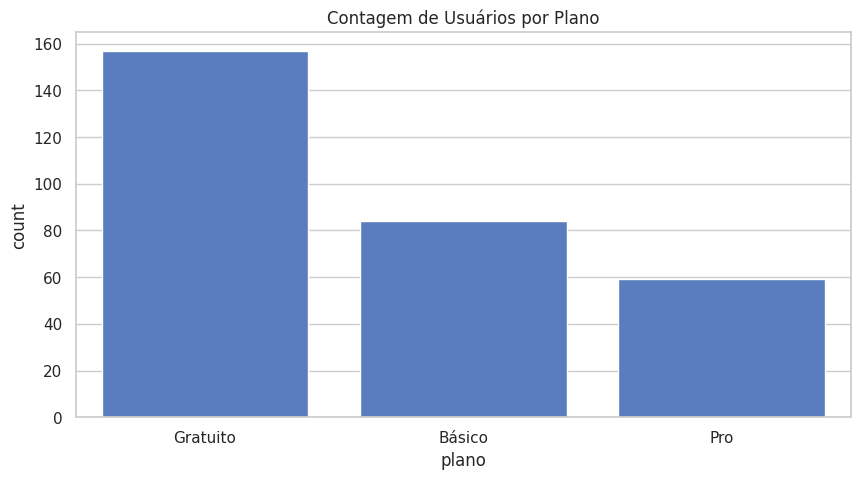

In [4]:
# Contagem por plano
plt.figure(figsize=(10, 5))
sns.countplot(data=df_sistema, x='plano', order=df_sistema['plano'].value_counts().index)
plt.title('Contagem de Usuários por Plano')
plt.show()

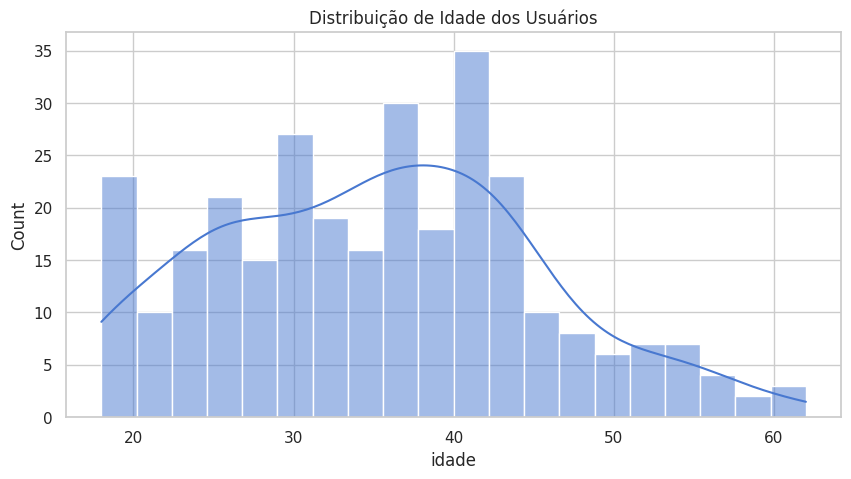

In [5]:
# Distribuição de idade
plt.figure(figsize=(10, 5))
sns.histplot(data=df_sistema, x='idade', kde=True, bins=20)
plt.title('Distribuição de Idade dos Usuários')
plt.show()

# Parte 2: Categóricas e Numéricas

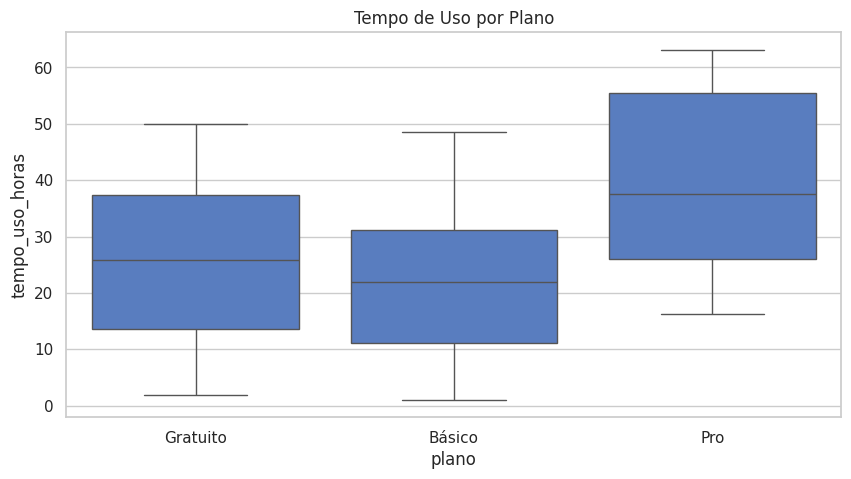

In [6]:
# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_sistema, x='plano', y='tempo_uso_horas')
plt.title('Tempo de Uso por Plano')
plt.show()

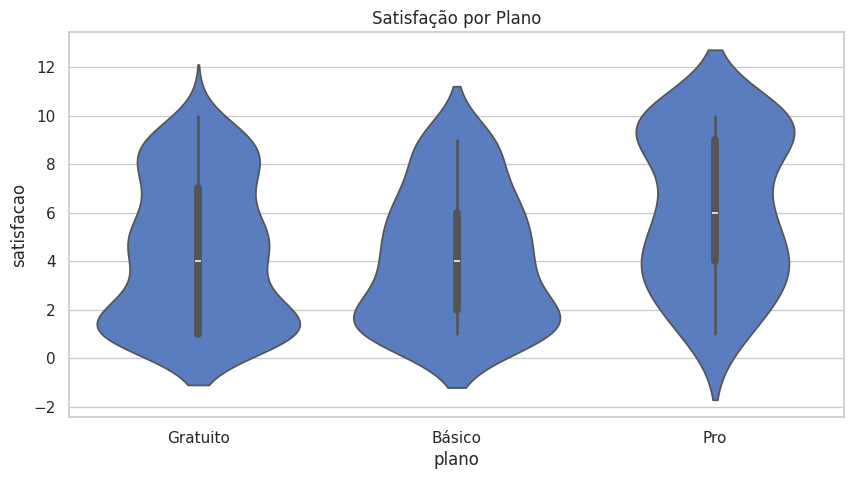

In [7]:
# Violinplot
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_sistema, x='plano', y='satisfacao')
plt.title('Satisfação por Plano')
plt.show()

# Parte 3: Correlações

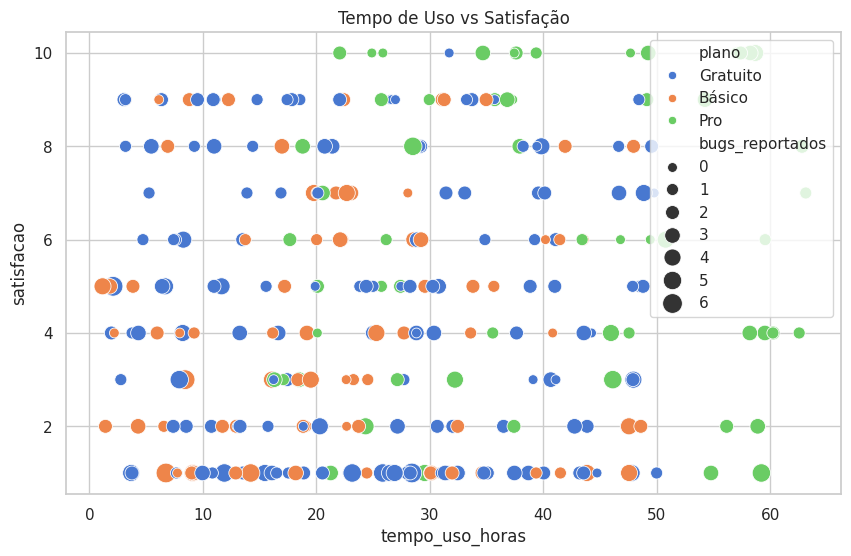

In [8]:
# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    size='bugs_reportados',
    sizes=(50, 200)
)
plt.title('Tempo de Uso vs Satisfação')
plt.show()

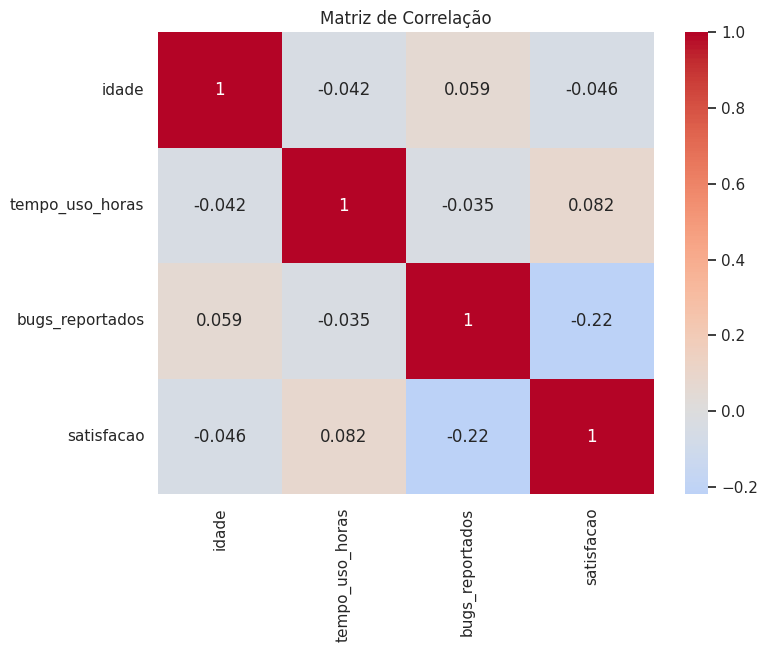

In [9]:
# Heatmap de correlação
plt.figure(figsize=(8, 6))
corr = df_sistema[['idade', 'tempo_uso_horas', 'bugs_reportados', 'satisfacao']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

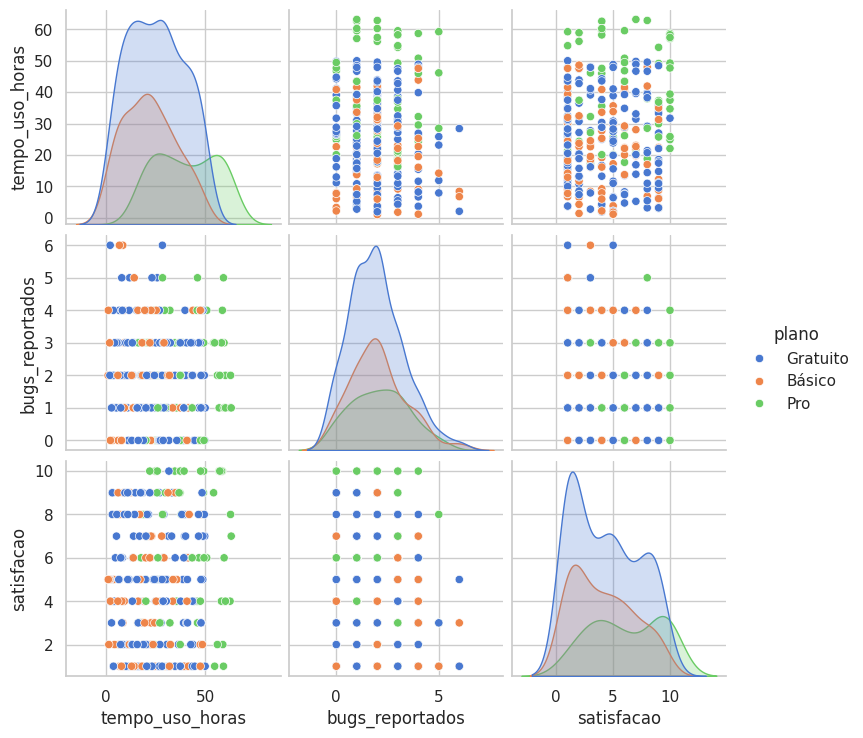

In [10]:
# Pairplot (bônus)
pairplot_df = df_sistema[['tempo_uso_horas', 'bugs_reportados', 'satisfacao', 'plano']]
sns.pairplot(pairplot_df, hue='plano', diag_kind='kde')
plt.show()